In [1]:
import numpy as np
import matplotlib.pyplot as plt

In [20]:
# define your plot style

best_style = {
    "font.family": "sans-serif",
    "mathtext.fontset": "custom",
    "mathtext.rm": "TeX Gyre Heros",
    "mathtext.bf": "TeX Gyre Heros:bold",
    "mathtext.sf": "TeX Gyre Heros",
    "mathtext.it": "TeX Gyre Heros:italic",
    "mathtext.tt": "TeX Gyre Heros",
    "mathtext.cal": "TeX Gyre Heros",
    "mathtext.default": "regular",
    "figure.figsize": (10.0, 10.0),
    "font.size": 26,
    "axes.labelsize": "medium",
    "axes.unicode_minus": False,
    "xtick.labelsize": "small",
    "ytick.labelsize": "small",
    "legend.fontsize": "small",
    "legend.handlelength": 1.5,
    "legend.borderpad": 0.5,
    "xtick.direction": "in",
    "xtick.major.size": 12,
    "xtick.minor.size": 6,
    "xtick.major.pad": 6,
    "xtick.top": True,
    "xtick.major.top": True,
    "xtick.major.bottom": True,
    "xtick.minor.top": True,
    "xtick.minor.bottom": True,
    "xtick.minor.visible": True,
    "ytick.direction": "in",
    "ytick.major.size": 12,
    "ytick.minor.size": 6.0,
    "ytick.right": True,
    "ytick.major.left": True,
    "ytick.major.right": True,
    "ytick.minor.left": True,
    "ytick.minor.right": True,
    "ytick.minor.visible": True,
    "grid.alpha": 0.8,
    "grid.linestyle": ":",
    "axes.linewidth": 2,
    "savefig.transparent": False,
}
plt.style.use(best_style)
cols = ["#5790fc", "#f89c20", "#009e73", "#964a8b", "#e42536", "#9c9ca1", "#7a21dd"]
# add a new color blind friendly color to this list
#set cols as the matplotlib default color cycle
plt.rcParams['axes.prop_cycle'] = plt.cycler(color=cols)

In [3]:
region = 'entire_region'
datadir = "entire_region_narrowprior_wom"
model_name1 = "entire_region_narrowprior_0p5M"
model_name2 = "entire_region_narrowprior_1M"
model_name3 = "entire_region_narrowprior_1p5M"
model_name4 = "entire_region_narrowprior"

posterior_path1 = f'/deepskieslab/stronglensing/hsbi/nre_posterior/{model_name1}/'
posterior_path2 = f'/deepskieslab/stronglensing/hsbi/nre_posterior/{model_name2}/'
posterior_path3 = f'/deepskieslab/stronglensing/hsbi/nre_posterior/{model_name3}/'
posterior_path4 = f'/deepskieslab/stronglensing/hsbi/nre_posterior/{model_name4}/'


figpath = f'/deepskieslab/stronglensing/hsbi/models/plots/evaluate/'

In [9]:
def read_mcmc_samples(posterior_path, datadir):
    posterior_data = np.load(posterior_path+f'{datadir}_mcmc.npz')
    flat_samples_list = posterior_data['flat_samples_list']
    samples_w_list = posterior_data['samples_w_list']
    samples_om_list = posterior_data['samples_om_list']
    true_w_list = posterior_data['true_w_list']
    true_om_list = posterior_data['true_om_list']
    return flat_samples_list, samples_w_list, samples_om_list, true_w_list, true_om_list

def compute_median_percentiles(samples_w_list, samples_om_list):
    w_median_list = []
    w_16_list = []
    w_84_list = []
    om_median_list = []
    om_16_list = []
    om_84_list = []

    for i in range(samples_w_list.shape[0]):
        w_median = np.median(samples_w_list[i])
        w_16, w_84 = np.percentile(samples_w_list[i], [16, 84])
        om_median = np.median(samples_om_list[i])
        om_16, om_84 = np.percentile(samples_om_list[i], [16, 84])

        w_median_list.append(w_median)
        w_16_list.append(w_16)
        w_84_list.append(w_84)

        om_median_list.append(om_median)
        om_16_list.append(om_16)
        om_84_list.append(om_84)

    return (np.array(w_median_list), np.array(w_16_list), np.array(w_84_list),
            np.array(om_median_list), np.array(om_16_list), np.array(om_84_list))

In [10]:
flat_samples_list1, samples_w_list1, samples_om_list1, true_w_list1, true_om_list1 = read_mcmc_samples(posterior_path1, datadir)
flat_samples_list2, samples_w_list2, samples_om_list2, true_w_list2, true_om_list2 = read_mcmc_samples(posterior_path2, datadir)
flat_samples_list3, samples_w_list3, samples_om_list3, true_w_list3, true_om_list3 = read_mcmc_samples(posterior_path3, datadir)
flat_samples_list4, samples_w_list4, samples_om_list4, true_w_list4, true_om_list4 = read_mcmc_samples(posterior_path4, datadir)

In [11]:
median_percentile_1 = compute_median_percentiles(samples_w_list1, samples_om_list1)
median_percentile_2 = compute_median_percentiles(samples_w_list2, samples_om_list2)
median_percentile_3 = compute_median_percentiles(samples_w_list3, samples_om_list3)
median_percentile_4 = compute_median_percentiles(samples_w_list4, samples_om_list4)

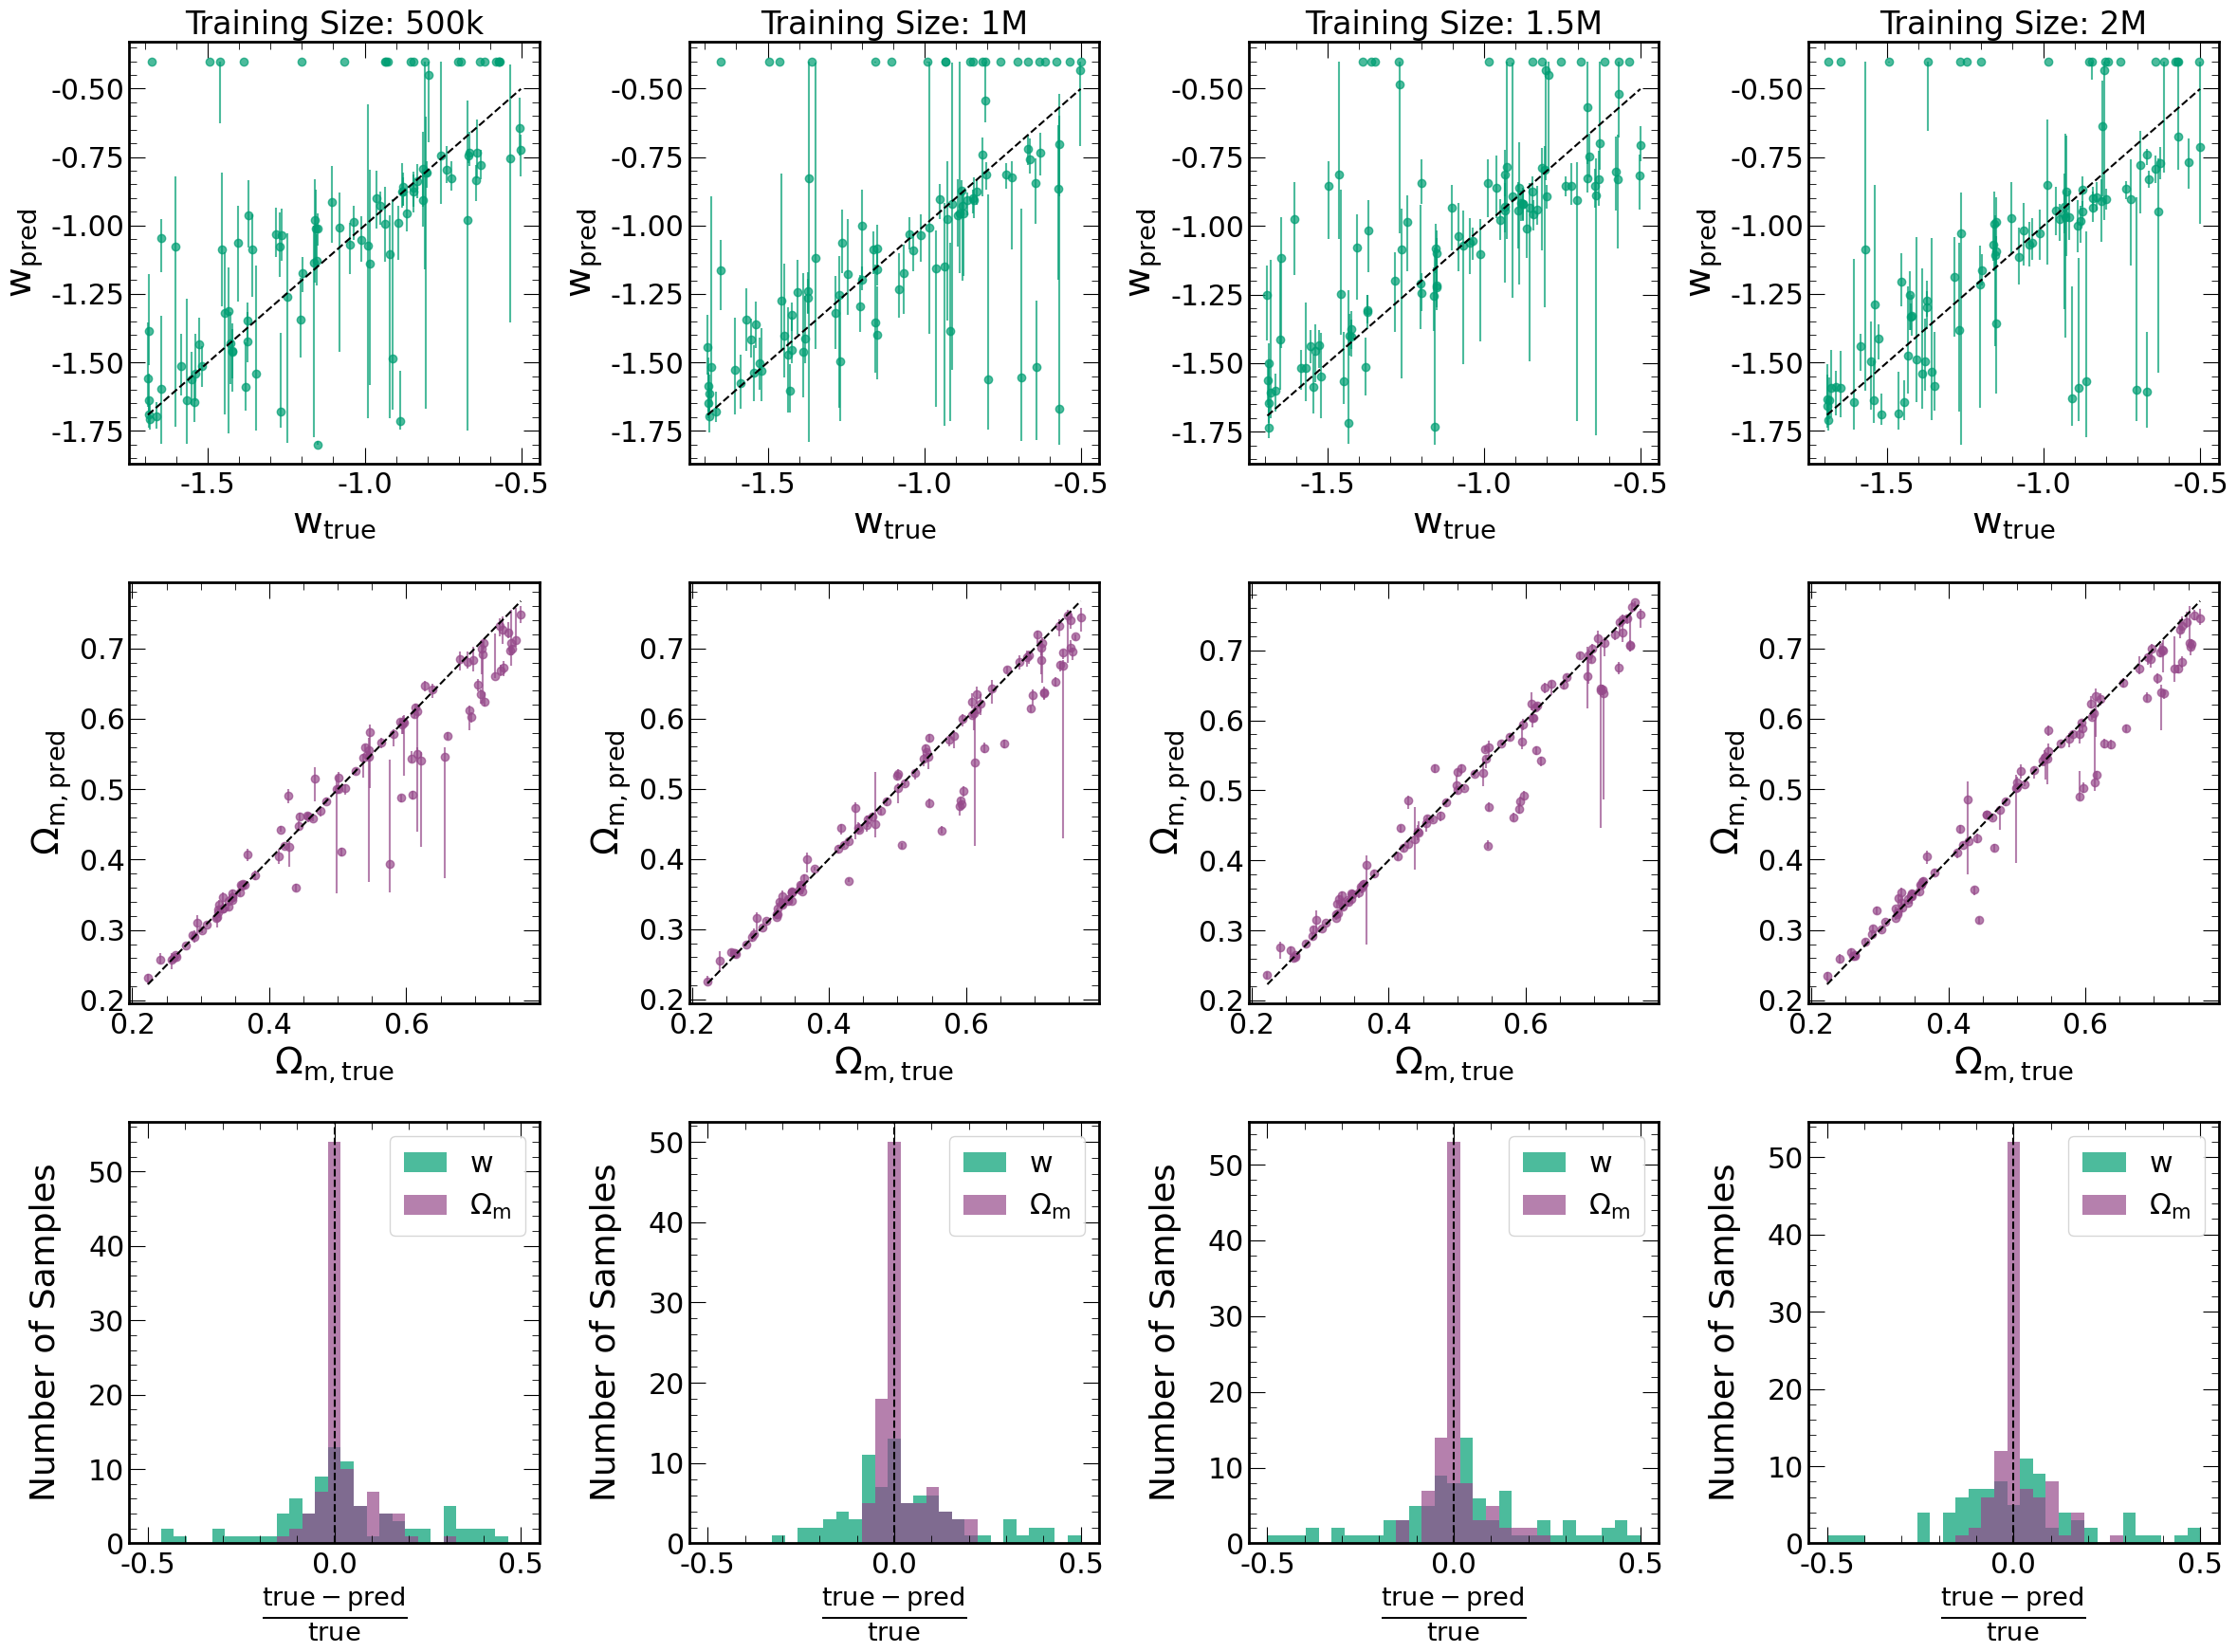

In [22]:
# plot scatter plot of true Vs predicted median for w and om for the 4 different training sizes as a 4 column, 3 rows subplot
# errorbars as yerr=[w_median_list - w_16_list, w_84_list - w_median_list] and similarly for om
# in third row, plot histograms of true - predicted median for w and om for the 4 different training sizes and overlay the histograms for w and om

fig, ((ax00, ax01, ax02, ax03), (ax10, ax11, ax12, ax13), (ax20, ax21, ax22, ax23)) = plt.subplots(3, 4, figsize=(24, 18))
# Top row: scatter plot of true Vs predicted median for w
w_median_list1, w_16_list1, w_84_list1, om_median_list1, om_16_list1, om_84_list1 = median_percentile_1
w_median_list2, w_16_list2, w_84_list2, om_median_list2, om_16_list2, om_84_list2 = median_percentile_2
w_median_list3, w_16_list3, w_84_list3, om_median_list3, om_16_list3, om_84_list3 = median_percentile_3
w_median_list4, w_16_list4, w_84_list4, om_median_list4, om_16_list4, om_84_list4 = median_percentile_4

# plot scatter plot of true Vs predicted median for w
ax00.errorbar(true_w_list1, w_median_list1, yerr=[w_median_list1 - w_16_list1, w_84_list1 - w_median_list1], fmt='o', label='500k', color='C2', alpha=0.7) 
ax00.plot([true_w_list1.min(), true_w_list1.max()], [true_w_list1.min(), true_w_list1.max()], 'k--', zorder=5)
ax00.set_ylabel(r'$w_{pred}$', fontsize=28)
ax00.set_xlabel(r'$w_{true}$', fontsize=28)
#ax00.legend(loc='lower right', fontsize=16)
ax01.errorbar(true_w_list2, w_median_list2, yerr=[w_median_list2 - w_16_list2, w_84_list2 - w_median_list2], fmt='o', label='1M', color='C2', alpha=0.7) 
ax01.plot([true_w_list2.min(), true_w_list2.max()], [true_w_list2.min(), true_w_list2.max()], 'k--', zorder=5)
ax01.set_ylabel(r'$w_{pred}$', fontsize=28)
ax01.set_xlabel(r'$w_{true}$', fontsize=28)
#ax01.legend(loc='lower right', fontsize=16)
ax02.errorbar(true_w_list3, w_median_list3, yerr=[w_median_list3 - w_16_list3, w_84_list3 - w_median_list3], fmt='o', label='1.5M', color='C2', alpha=0.7) 
ax02.plot([true_w_list3.min(), true_w_list3.max()], [true_w_list3.min(), true_w_list3.max()], 'k--', zorder=5)
ax02.set_ylabel(r'$w_{pred}$', fontsize=28)
ax02.set_xlabel(r'$w_{true}$', fontsize=28)
#ax02.legend(loc='lower right', fontsize=16)
ax03.errorbar(true_w_list4, w_median_list4, yerr=[w_median_list4 - w_16_list4, w_84_list4 - w_median_list4], fmt='o', label='2M', color='C2', alpha=0.7) 
ax03.plot([true_w_list4.min(), true_w_list4.max()], [true_w_list4.min(), true_w_list4.max()], 'k--', zorder=5)
ax03.set_ylabel(r'$w_{pred}$', fontsize=28)
ax03.set_xlabel(r'$w_{true}$', fontsize=28)
#ax03.legend(loc='lower right', fontsize=16)

ax00.set_title('Training Size: 500k', fontsize=24)
ax01.set_title('Training Size: 1M', fontsize=24)
ax02.set_title('Training Size: 1.5M', fontsize=24)
ax03.set_title('Training Size: 2M', fontsize=24)

# plot scatter plot of true Vs predicted median for om
ax10.errorbar(true_om_list1, om_median_list1, yerr=[om_median_list1 - om_16_list1, om_84_list1 - om_median_list1], fmt='o', label='500k', color='C3', alpha=0.7)
ax10.plot([true_om_list1.min(), true_om_list1.max()], [true_om_list1.min(), true_om_list1.max()], 'k--', zorder=5)
ax10.set_ylabel(r'$\Omega_{m,pred}$',   fontsize=28)
ax10.set_xlabel(r'$\Omega_{m,true}$', fontsize=28)
# ax10.legend(loc='lower right', fontsize=16)
ax11.errorbar(true_om_list2, om_median_list2, yerr=[om_median_list2 - om_16_list2, om_84_list2 - om_median_list2], fmt='o', label='1M', color='C3', alpha=0.7)
ax11.plot([true_om_list2.min(), true_om_list2.max()], [true_om_list2.min(), true_om_list2.max()], 'k--', zorder=5)
ax11.set_ylabel(r'$\Omega_{m,pred}$',   fontsize=28)
ax11.set_xlabel(r'$\Omega_{m,true}$', fontsize=28)
# ax11.legend(loc='lower right', fontsize=16)
ax12.errorbar(true_om_list3, om_median_list3, yerr=[om_median_list3 - om_16_list3, om_84_list3 - om_median_list3], fmt='o', label='1.5M', color='C3', alpha=0.7)
ax12.plot([true_om_list3.min(), true_om_list3.max()], [true_om_list3.min(), true_om_list3.max()], 'k--', zorder=5)
ax12.set_ylabel(r'$\Omega_{m,pred}$',   fontsize=28)
ax12.set_xlabel(r'$\Omega_{m,true}$', fontsize=28)
# ax12.legend(loc='lower right', fontsize=16)
ax13.errorbar(true_om_list4, om_median_list4, yerr=[om_median_list4 - om_16_list4, om_84_list4 - om_median_list4], fmt='o', label='2M', color='C3', alpha=0.7)
ax13.plot([true_om_list4.min(), true_om_list4.max()], [true_om_list4.min(), true_om_list4.max()], 'k--', zorder=5)
ax13.set_ylabel(r'$\Omega_{m,pred}$',   fontsize=28)
ax13.set_xlabel(r'$\Omega_{m,true}$', fontsize=28)
# ax13.legend(loc='lower right', fontsize=16) 

# Bottom row: histogram of true - median predicted for w and om overlaid for each training size
# histograms of (true - predicted median)/true for w
residuals_w1 = (true_w_list1 - w_median_list1) / true_w_list1
residuals_w2 = (true_w_list2 - w_median_list2) / true_w_list2
residuals_w3 = (true_w_list3 - w_median_list3) / true_w_list3
residuals_w4 = (true_w_list4 - w_median_list4) / true_w_list4

residuals_om1 = (true_om_list1 - om_median_list1) / true_om_list1
residuals_om2 = (true_om_list2 - om_median_list2) / true_om_list2
residuals_om3 = (true_om_list3 - om_median_list3) / true_om_list3
residuals_om4 = (true_om_list4 - om_median_list4) / true_om_list4

bins = np.linspace(-0.5, 0.5, 30)
hist1, _ = np.histogram(residuals_w1, bins=bins)
hist2, _ = np.histogram(residuals_w2, bins=bins)
hist3, _ = np.histogram(residuals_w3, bins=bins)
hist4, _ = np.histogram(residuals_w4, bins=bins)

hist5, _ = np.histogram(residuals_om1, bins=bins)
hist6, _ = np.histogram(residuals_om2, bins=bins)
hist7, _ = np.histogram(residuals_om3, bins=bins)
hist8, _ = np.histogram(residuals_om4, bins=bins)


ax20.hist(bins[:-1], bins, weights=hist1, alpha=0.7, color='C2', label=r'$w$')
ax20.hist(bins[:-1], bins, weights=hist5, alpha=0.7, color='C3', label=r'$\Omega_{m}$')
ax21.hist(bins[:-1], bins, weights=hist2, alpha=0.7, color='C2', label=r'$w$')
ax21.hist(bins[:-1], bins, weights=hist6, alpha=0.7, color='C3', label=r'$\Omega_{m}$')
ax22.hist(bins[:-1], bins, weights=hist3, alpha=0.7, color='C2', label=r'$w$')
ax22.hist(bins[:-1], bins, weights=hist7, alpha=0.7, color='C3', label=r'$\Omega_{m}$')
ax23.hist(bins[:-1], bins, weights=hist4, alpha=0.7, color='C2', label=r'$w$')
ax23.hist(bins[:-1], bins, weights=hist8, alpha=0.7, color='C3', label=r'$\Omega_{m}$')

ax20.set_xlabel(r'$\frac{true - pred}{true}$', fontsize=28)
ax20.set_ylabel('Number of Samples', fontsize=26, labelpad=20)
ax20.axvline(0, color='k', linestyle='--', lw=1.5)
ax20.legend(loc='upper right')
ax21.set_xlabel(r'$\frac{true - pred}{true}$', fontsize=28)
ax21.set_ylabel('Number of Samples', fontsize=26, labelpad=20)
ax21.axvline(0, color='k', linestyle='--', lw=1.5)
ax21.legend(loc='upper right')
ax22.set_xlabel(r'$\frac{true - pred}{true}$', fontsize=28)
ax22.set_ylabel('Number of Samples', fontsize=26, labelpad=20)      
ax22.axvline(0, color='k', linestyle='--', lw=1.5)
ax22.legend(loc='upper right')
ax23.set_xlabel(r'$\frac{true - pred}{true}$', fontsize=28)
ax23.set_ylabel('Number of Samples', fontsize=26, labelpad=20)
ax23.axvline(0, color='k', linestyle='--', lw=1.5)
ax23.legend(loc='upper right')



plt.tight_layout()
#plt.show()
plt.savefig(figpath+f'compare_train_size.pdf', dpi=300)